##Instalación de librerías

In [1]:
# Instalación de dependencias para CLIP
!pip install torch torchvision torchaudio ftfy regex tqdm --quiet
!pip install git+https://github.com/openai/CLIP.git --quiet
!pip install requests Pillow matplotlib numpy --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


##Importaciones y configuración del dispositivo

In [2]:
import clip
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import requests
from io import BytesIO
import warnings
warnings.filterwarnings('ignore')

##Cargar el modelo CLIP

In [5]:
import torch

# Modelos disponibles: RN50, RN101, RN50x4, RN50x16, ViT-B/32, ViT-B/16, ViT-L/14
MODEL_NAME = "ViT-B/32"  # Buen balance entre velocidad y precisión

device = "cuda" if torch.cuda.is_available() else "cpu"

model, preprocess = clip.load(MODEL_NAME, device=device)
model.eval()  # Modo inferencia

print(f' Modelo {MODEL_NAME} cargado correctamente!')
print(f'   Parámetros totales: {sum(p.numel() for p in model.parameters()):,}')

100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 165MiB/s]


 Modelo ViT-B/32 cargado correctamente!
   Parámetros totales: 151,277,313


##Funciones auxiliares

Definimos funciones reutilizables para cargar imágenes y visualizar resultados.

In [23]:
def load_image_from_url(url):
    """Descarga una imagen desde una URL y la devuelve como PIL Image."""
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    }
    response = requests.get(url, timeout=10, headers=headers)

    response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
    return Image.open(BytesIO(response.content)).convert('RGB')


def classify_image(image, labels, model, preprocess, device):
    """
    Clasifica una imagen PIL contra una lista de etiquetas de texto.

    Args:
        image: PIL Image
        labels: lista de strings con las etiquetas
        model, preprocess: modelo CLIP y su preprocesador
        device: 'cuda' o 'cpu'

    Returns:
        probs: array numpy con probabilidades para cada etiqueta
    """
    # Preprocesar imagen
    image_input = preprocess(image).unsqueeze(0).to(device)

    # Tokenizar etiquetas
    text_input = clip.tokenize(labels).to(device)

    # Calcular embeddings y similitud
    with torch.no_grad():
        image_features = model.encode_image(image_input)
        text_features  = model.encode_text(text_input)

        # Normalizar vectores (cosine similarity)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        text_features  = text_features  / text_features.norm(dim=-1, keepdim=True)

        # Logits y probabilidades
        logits_per_image, _ = model(image_input, text_input)
        probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0]

    return probs


def plot_classification(image, labels, probs, title='Clasificación CLIP'):
    """
    Visualiza la imagen junto con el gráfico de probabilidades.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor('#0f0f1a')

    # --- Panel izquierdo: imagen ---
    ax_img = axes[0]
    ax_img.imshow(image)
    ax_img.axis('off')
    ax_img.set_title('Imagen de entrada', color='white', fontsize=13, pad=10)

    # --- Panel derecho: probabilidades ---
    ax_bar = axes[1]
    ax_bar.set_facecolor('#1a1a2e')

    sorted_idx  = np.argsort(probs)  # ascendente para barh
    sorted_lbls = [labels[i] for i in sorted_idx]
    sorted_prob = probs[sorted_idx]

    # Colores: el mejor resultado en color acento, el resto en gris
    colors = ['#4a4a8a'] * len(sorted_lbls)
    colors[-1] = '#7c6bff'  # mejor predicción

    bars = ax_bar.barh(sorted_lbls, sorted_prob * 100, color=colors,
                       edgecolor='none', height=0.6)

    # Etiquetas de porcentaje
    for bar, prob in zip(bars, sorted_prob):
        ax_bar.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                    f'{prob*100:.1f}%', va='center', ha='left',
                    color='white', fontsize=10)

    ax_bar.set_xlim(0, max(sorted_prob * 100) * 1.2)
    ax_bar.set_xlabel('Probabilidad (%)', color='#aaaacc', fontsize=11)
    ax_bar.set_title('Distribución de probabilidades', color='white', fontsize=13, pad=10)
    ax_bar.tick_params(colors='#aaaacc')
    ax_bar.spines['top'].set_visible(False)
    ax_bar.spines['right'].set_visible(False)
    ax_bar.spines['bottom'].set_color('#333355')
    ax_bar.spines['left'].set_color('#333355')

    best_label = labels[np.argmax(probs)]
    best_prob  = probs.max()

    fig.suptitle(f'{title}\n Predicción: "{best_label}"  ({best_prob*100:.1f}%)',
                 color='white', fontsize=14, y=1.02)

    plt.tight_layout()
    plt.show()

    return best_label, best_prob

##Clasificación básica: una imagen, varias etiquetas

Empezamos con un ejemplo sencillo para entender el flujo.

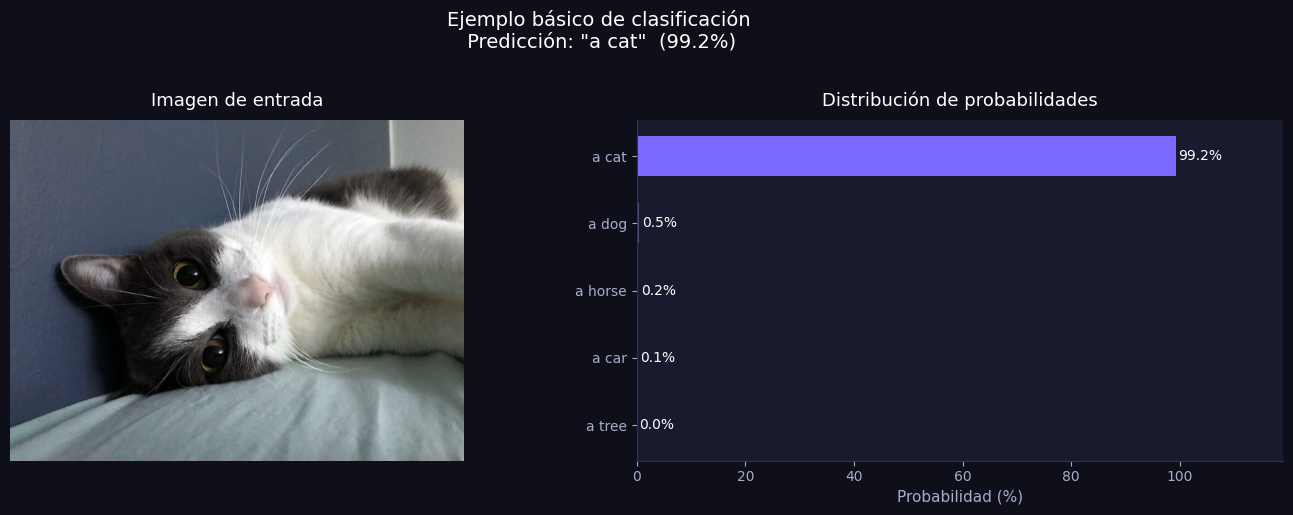


 Resultados detallados:
Etiqueta                  Probabilidad
──────────────────────────────────────
a cat                        99.19%  ███████████████████████████████████████
a dog                         0.47%  
a horse                       0.24%  
a car                         0.06%  
a tree                        0.04%  


In [24]:
# ── Imagen de prueba (gato) ──────────────────────────────────────────────────
IMAGE_URL = 'https://unamglobal.unam.mx/wp-content/uploads/2025/08/GATO_UNAM-1024x768.jpg'
image = load_image_from_url(IMAGE_URL)

# ── Etiquetas candidatas ─────────────────────────────────────────────────────
labels = [
    "a cat",
    "a dog",
    "a horse",
    "a car",
    "a tree"
]

# ── Clasificar ───────────────────────────────────────────────────────────────
probs = classify_image(image, labels, model, preprocess, device)

# ── Visualizar ───────────────────────────────────────────────────────────────
best_label, best_prob = plot_classification(image, labels, probs,
                                            title='Ejemplo básico de clasificación')

# ── Tabla de resultados ───────────────────────────────────────────────────────
print('\n Resultados detallados:')
print(f'{"Etiqueta":<25} {"Probabilidad":>12}')
print('─' * 38)
for label, prob in sorted(zip(labels, probs), key=lambda x: -x[1]):
    bar = '█' * int(prob * 40)
    print(f'{label:<25} {prob*100:>8.2f}%  {bar}')

##Experimentación con prompts descriptivos

CLIP entiende descripciones complejas, no solo palabras clave. Aquí probamos cómo afecta el detalle del prompt.

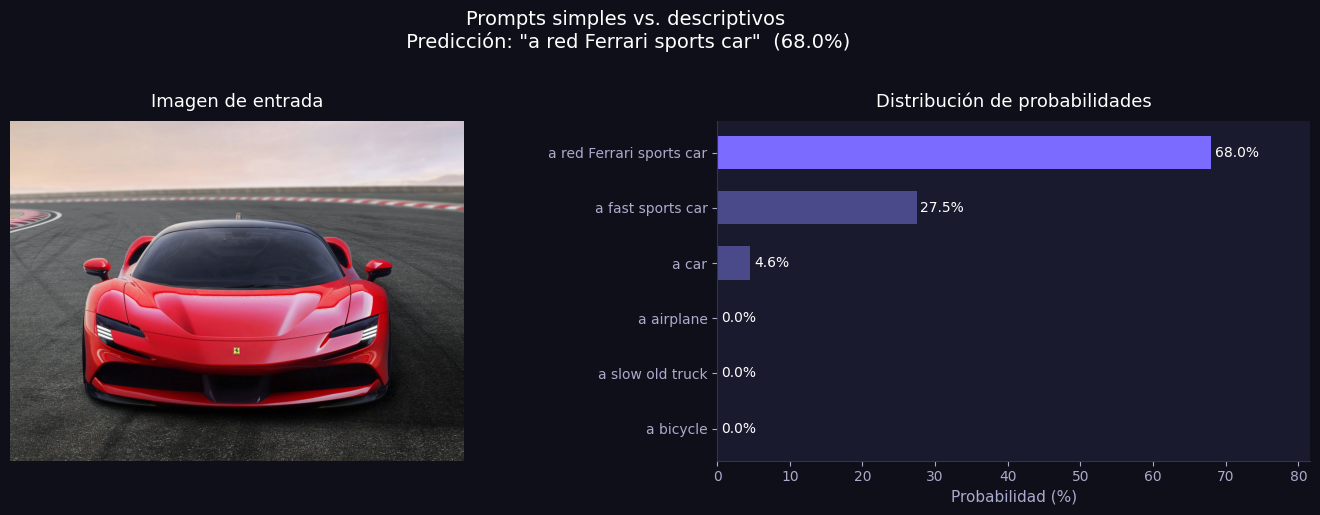

\ Observación: CLIP beneficia de descripciones más específicas!


In [26]:
# Imagen de un auto deportivo
CAR_URL = 'https://media.wired.com/photos/5ceeed5b0bdd96c34c6174a3/master/w_1600%2Cc_limit/01_Ferrari_SF90_03.jpg'
car_image = load_image_from_url(CAR_URL)

# Etiquetas con distintos niveles de detalle
descriptive_labels = [
    "a car",
    "a fast sports car",
    "a red Ferrari sports car",
    "a slow old truck",
    "a bicycle",
    "a airplane"
]

probs = classify_image(car_image, descriptive_labels, model, preprocess, device)
plot_classification(car_image, descriptive_labels, probs,
                    title='Prompts simples vs. descriptivos')

print('\ Observación: CLIP beneficia de descripciones más específicas!')

##Prompts con modificadores de calidad y estilo

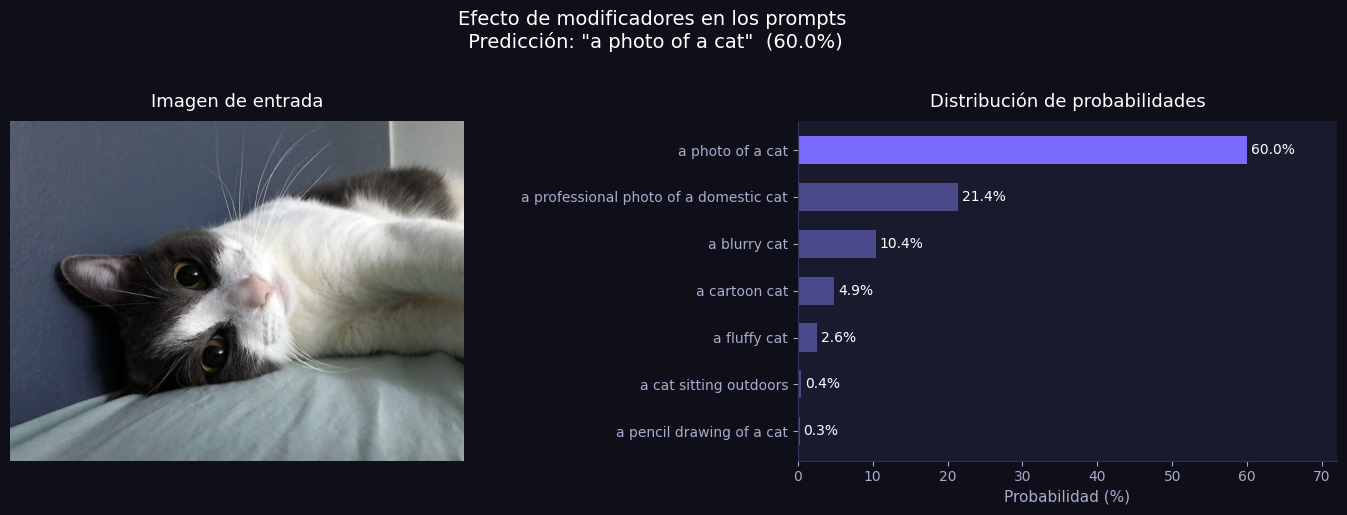

('a photo of a cat', np.float16(0.6))

In [27]:
# Volvemos a la imagen del gato
image = load_image_from_url(IMAGE_URL)

# Prompts con modificadores
modifier_labels = [
    "a blurry cat",
    "a fluffy cat",
    "a cat sitting outdoors",
    "a photo of a cat",
    "a pencil drawing of a cat",
    "a cartoon cat",
    "a professional photo of a domestic cat"
]

probs = classify_image(image, modifier_labels, model, preprocess, device)
plot_classification(image, modifier_labels, probs,
                    title='Efecto de modificadores en los prompts')


##Clasificación por lotes (Batch)

Podemos clasificar múltiples imágenes a la vez de forma eficiente.

Descargando imágenes del lote...
   Gato cargado
   Perro cargado
   Automóvil cargado
   Árbol cargado

 Inferencia en lote completada! Forma de salida: (4, 6)


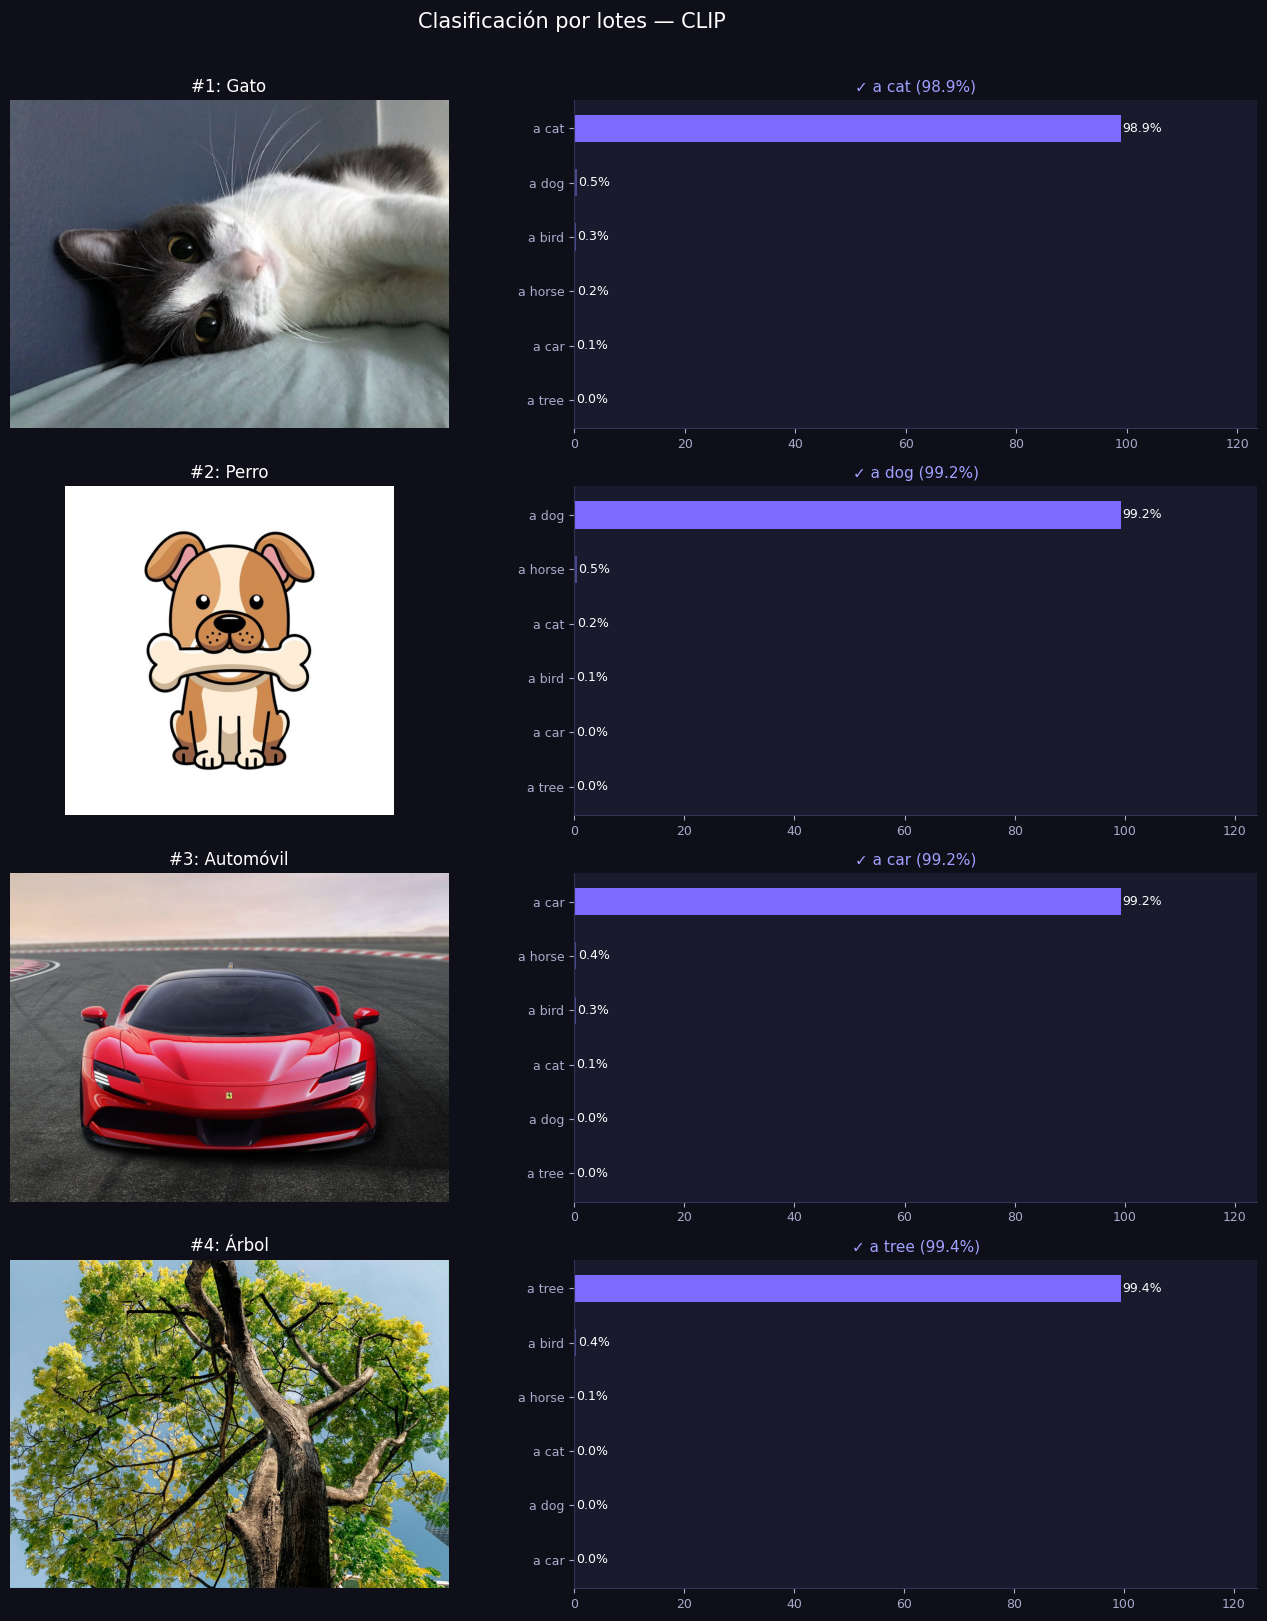

In [30]:
# ── Definir lote de imágenes y sus URLs ──────────────────────────────────────
batch_images_info = [
    {
        'name': 'Gato',
        'url': 'https://unamglobal.unam.mx/wp-content/uploads/2025/08/GATO_UNAM-1024x768.jpg'
    },
    {
        'name': 'Perro',
        'url': 'https://www.shutterstock.com/image-vector/cute-vector-icon-clipart-dog-600nw-2520386915.jpg'
    },
    {
        'name': 'Automóvil',
        'url': 'https://media.wired.com/photos/5ceeed5b0bdd96c34c6174a3/master/w_1600%2Cc_limit/01_Ferrari_SF90_03.jpg'
    },
    {
        'name': 'Árbol',
        'url': 'https://images.pexels.com/photos/4147343/pexels-photo-4147343.jpeg'
    }
]

# Etiquetas compartidas para todos
shared_labels = ["a cat", "a dog", "a car", "a tree", "a bird", "a horse"]

# ── Cargar y preprocesar todas las imágenes ───────────────────────────────────
pil_images = []
processed   = []
for info in batch_images_info:
    try:
        img = load_image_from_url(info['url'])
        pil_images.append(img)
        processed.append(preprocess(img))
        print(f'   {info["name"]} cargado')
    except Exception as e:
        print(f'   Error en {info["name"]}: {e}')

# Apilar en tensor batch
image_batch = torch.stack(processed).to(device)
text_tokens  = clip.tokenize(shared_labels).to(device)

# ── Inferencia en batch ───────────────────────────────────────────────────────
with torch.no_grad():
    logits_per_image, _ = model(image_batch, text_tokens)
    batch_probs = logits_per_image.softmax(dim=-1).cpu().numpy()

print(f'\n Inferencia en lote completada! Forma de salida: {batch_probs.shape}')

# ── Visualizar resultados del lote ────────────────────────────────────────────
fig, axes = plt.subplots(len(pil_images), 2, figsize=(14, 4 * len(pil_images)))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('Clasificación por lotes — CLIP', color='white', fontsize=15, y=1.01)

for i, (img, info, probs) in enumerate(zip(pil_images, batch_images_info, batch_probs)):
    # Imagen
    axes[i, 0].imshow(img)
    axes[i, 0].axis('off')
    axes[i, 0].set_title(f'#{i+1}: {info["name"]}', color='white', fontsize=12)

    # Barras
    ax = axes[i, 1]
    ax.set_facecolor('#1a1a2e')
    sorted_idx  = np.argsort(probs)
    sorted_lbls = [shared_labels[j] for j in sorted_idx]
    sorted_probs = probs[sorted_idx]
    colors = ['#4a4a8a'] * len(sorted_lbls)
    colors[-1] = '#7c6bff'

    bars = ax.barh(sorted_lbls, sorted_probs * 100, color=colors, height=0.5)
    for bar, p in zip(bars, sorted_probs):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{p*100:.1f}%', va='center', ha='left', color='white', fontsize=9)

    best = shared_labels[np.argmax(probs)]
    ax.set_title(f'✓ {best} ({probs.max()*100:.1f}%)', color='#a0a0ff', fontsize=11)
    ax.tick_params(colors='#aaaacc', labelsize=9)
    ax.set_xlim(0, max(sorted_probs * 100) * 1.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('#333355')
    ax.spines['left'].set_color('#333355')

plt.tight_layout()
plt.show()

##BONUS: Frases ambiguas y subjetivas

Exploramos cómo CLIP interpreta conceptos abstractos como emociones y peligrosidad.

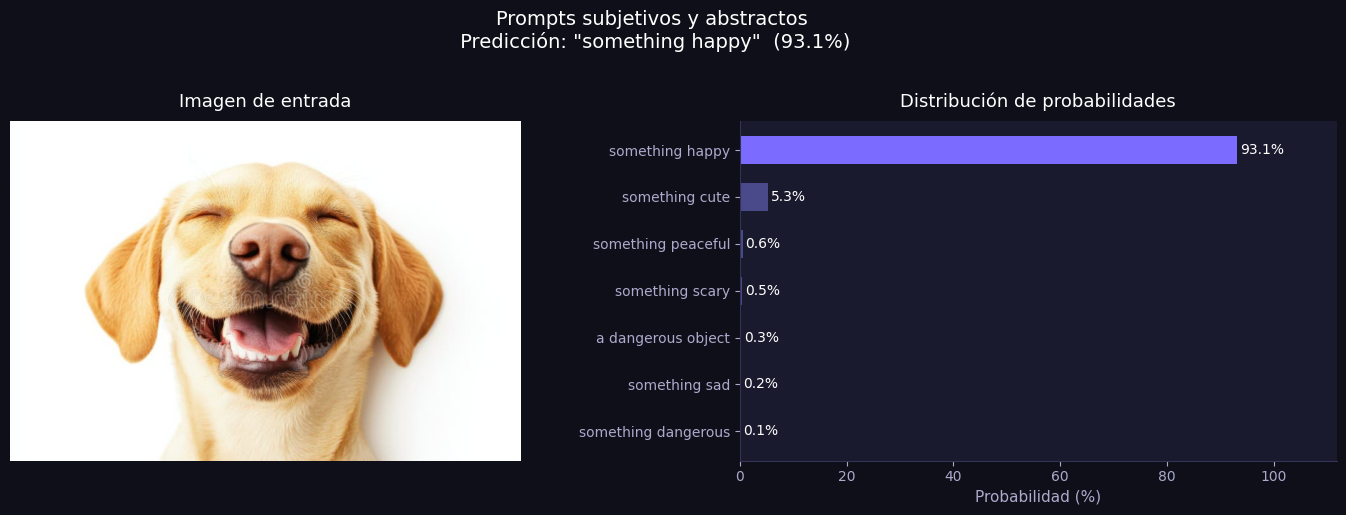


 CLIP asigna probabilidades incluso a conceptos abstractos,
   interpretando el contenido visual de forma semántica.


In [32]:
# Imagen de un perro feliz
DOG_URL = 'https://thumbs.dreamstime.com/b/cierre-de-un-perro-sonriente-muy-feliz-con-fondo-blanco-349842377.jpg'
dog_image = load_image_from_url(DOG_URL)

# Etiquetas subjetivas / ambiguas
subjective_labels = [
    "something happy",
    "something sad",
    "something dangerous",
    "something cute",
    "something scary",
    "something peaceful",
    "a dangerous object"
]

probs = classify_image(dog_image, subjective_labels, model, preprocess, device)
plot_classification(dog_image, subjective_labels, probs,
                    title='Prompts subjetivos y abstractos')

print('\n CLIP asigna probabilidades incluso a conceptos abstractos,')
print('   interpretando el contenido visual de forma semántica.')

##BONUS: Análisis de embeddings con similitud coseno

Exploramos los vectores internos de CLIP para entender la similitud semántica.

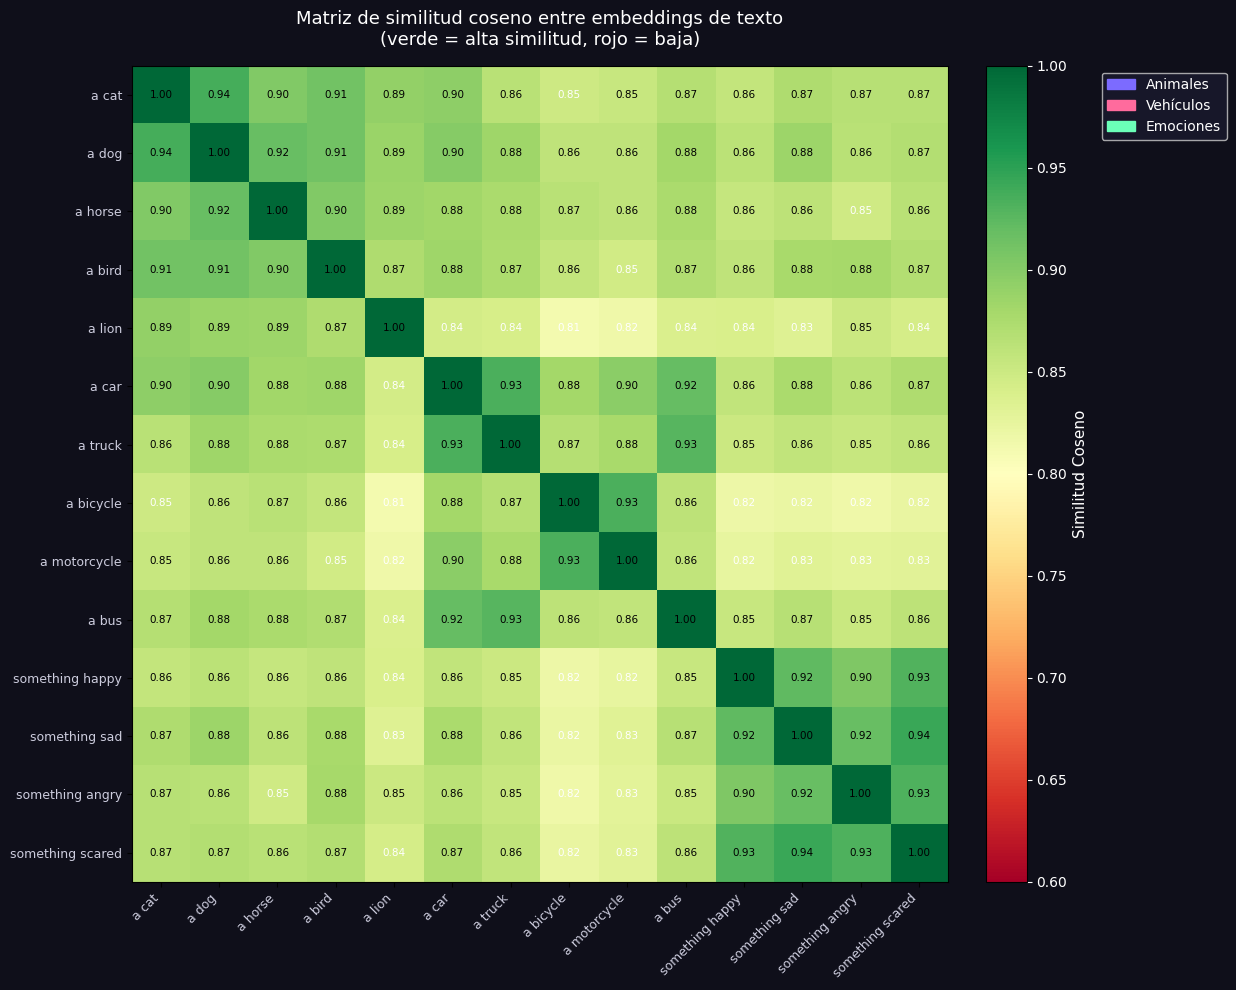


💡 Observación: textos del mismo grupo semántico tienen mayor similitud.


In [33]:
# Grupos de textos para comparar su similitud
text_groups = {
    'Animales': ['a cat', 'a dog', 'a horse', 'a bird', 'a lion'],
    'Vehículos': ['a car', 'a truck', 'a bicycle', 'a motorcycle', 'a bus'],
    'Emociones': ['something happy', 'something sad', 'something angry', 'something scared']
}

all_texts = []
group_labels = []
colors_map = {'Animales': '#7c6bff', 'Vehículos': '#ff6b9d', 'Emociones': '#6bffb8'}

for group, texts in text_groups.items():
    all_texts.extend(texts)
    group_labels.extend([group] * len(texts))

# Obtener embeddings de texto
tokens = clip.tokenize(all_texts).to(device)
with torch.no_grad():
    text_feats = model.encode_text(tokens).float()
    text_feats = text_feats / text_feats.norm(dim=-1, keepdim=True)

# Matriz de similitud coseno
sim_matrix = (text_feats @ text_feats.T).cpu().numpy()

# ── Visualizar heatmap ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#0f0f1a')

im = ax.imshow(sim_matrix, cmap='RdYlGn', vmin=0.6, vmax=1.0)

# Ejes
ax.set_xticks(range(len(all_texts)))
ax.set_yticks(range(len(all_texts)))
ax.set_xticklabels(all_texts, rotation=45, ha='right', fontsize=9, color='#ccccdd')
ax.set_yticklabels(all_texts, fontsize=9, color='#ccccdd')

# Valores en celdas
for i in range(len(all_texts)):
    for j in range(len(all_texts)):
        val = sim_matrix[i, j]
        txt_color = 'black' if val > 0.85 else 'white'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=7.5, color=txt_color)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Similitud Coseno', color='white', fontsize=11)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

ax.set_title('Matriz de similitud coseno entre embeddings de texto\n'
             '(verde = alta similitud, rojo = baja)',
             color='white', fontsize=13, pad=15)

# Leyenda de grupos
patches = [mpatches.Patch(color=c, label=g) for g, c in colors_map.items()]
ax.legend(handles=patches, loc='upper right', bbox_to_anchor=(1.35, 1.0),
          facecolor='#1a1a2e', labelcolor='white', fontsize=10)

plt.tight_layout()
plt.show()

print('\n💡 Observación: textos del mismo grupo semántico tienen mayor similitud.')

##BONUS: Búsqueda de imagen en colección con CLIP

CLIP también permite hacer búsqueda texto→imagen: dado un texto, ¿cuál imagen se parece más?

Consulta: "outdoor nature scenery"
Cargando colección...
   Gato
   Perrito
   Ferrari rojo
   Naturaleza


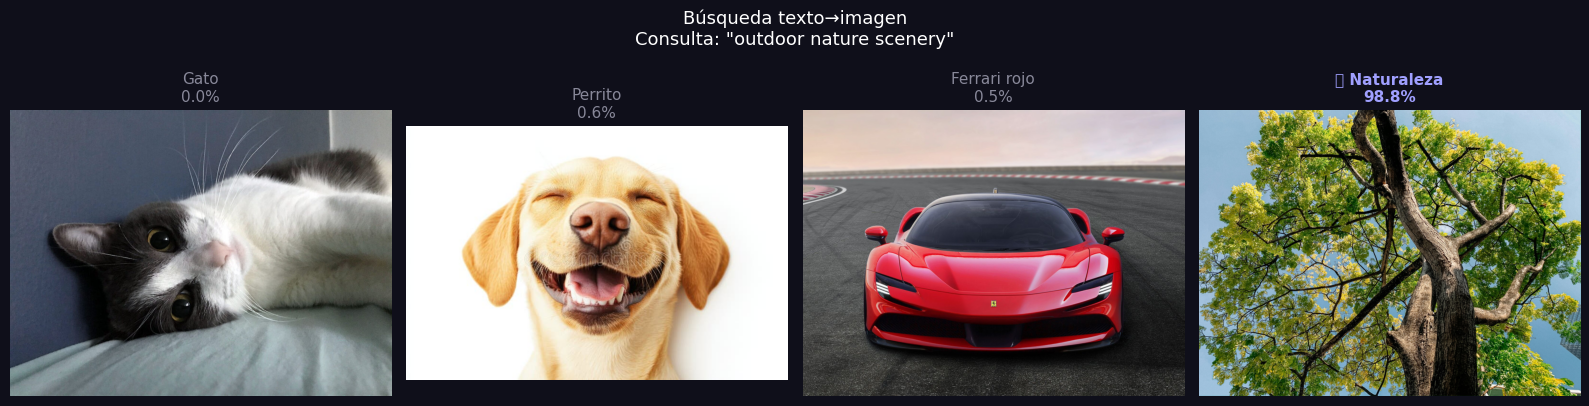


 Imagen más similar: "Naturaleza" (98.8%)


In [36]:
# Colección de imágenes
image_collection = [
    {'name': 'Gato',  'url': 'https://unamglobal.unam.mx/wp-content/uploads/2025/08/GATO_UNAM-1024x768.jpg'},
    {'name': 'Perrito',       'url': 'https://thumbs.dreamstime.com/b/cierre-de-un-perro-sonriente-muy-feliz-con-fondo-blanco-349842377.jpg'},
    {'name': 'Ferrari rojo',   'url': 'https://media.wired.com/photos/5ceeed5b0bdd96c34c6174a3/master/w_1600%2Cc_limit/01_Ferrari_SF90_03.jpg'},
    {'name': 'Naturaleza',     'url': 'https://images.pexels.com/photos/4147343/pexels-photo-4147343.jpeg'}
]

# ── Consulta de texto (¡modifícala!) ─────────────────────────────────────────
QUERY = "outdoor nature scenery"   # <── cambia esto para experimentar
# Otras ideas:
# "a fast red sports car"
# "a fluffy domestic animal"
# "something cute and friendly"
# ─────────────────────────────────────────────────────────────────────────────

print(f'Consulta: "{QUERY}"\nCargando colección...')
coll_images = []
coll_tensors = []
for item in image_collection:
    try:
        img = load_image_from_url(item['url'])
        coll_images.append(img)
        coll_tensors.append(preprocess(img))
        print(f'   {item["name"]}')
    except:
        print(f'   {item["name"]} (error)')

img_batch  = torch.stack(coll_tensors).to(device)
text_token = clip.tokenize([QUERY]).to(device)

with torch.no_grad():
    img_feats  = model.encode_image(img_batch)
    txt_feat   = model.encode_text(text_token)
    img_feats  = img_feats / img_feats.norm(dim=-1, keepdim=True)
    txt_feat   = txt_feat  / txt_feat.norm(dim=-1, keepdim=True)
    similarities = (100 * img_feats @ txt_feat.T).squeeze().cpu().numpy()

# Normalizar a probabilidades
scores = torch.tensor(similarities).softmax(dim=0).numpy()
best_idx = np.argmax(scores)

# ── Visualizar ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(coll_images), figsize=(4 * len(coll_images), 4.5))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle(f'Búsqueda texto→imagen\nConsulta: "{QUERY}"',
             color='white', fontsize=13)

for i, (img, item) in enumerate(zip(coll_images, image_collection)):
    ax = axes[i]
    border_color = '#7c6bff' if i == best_idx else '#2a2a4a'
    ax.imshow(img)
    ax.axis('off')
    label = f'{item["name"]}\n{scores[i]*100:.1f}%'
    if i == best_idx:
        label = '🏆 ' + label
    ax.set_title(label, color='#a0a0ff' if i == best_idx else '#888899',
                 fontsize=11, fontweight='bold' if i == best_idx else 'normal')
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3 if i == best_idx else 0.5)

plt.tight_layout()
plt.show()

print(f'\n Imagen más similar: "{image_collection[best_idx]["name"]}" ({scores[best_idx]*100:.1f}%)')